# Payout Trigger

## 0. Imports

In [8]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv("data/test_predictions_for_trigger.csv")

## 1. Defining a Catastrophic Flood Threshold
Here, we define which level of predicted flood risk counts as a serious, payout-triggering event. We define the binary variable `is_catastrophe` which takes the value of 1 if it is a major flood, and 0 otherwise. We classify catastrophic floods as observations in the upper tail of the predicted flood probability distribution (specifically, we use a top 5% threshold); this approximates the low-probability, high-impact events commonly used in reinsurance and ensures that the trigger are both data-driven and aligned with industry practices for parametric insurance.

In [13]:
# Define the 'Ground Truth' catastrophe as the top 5% of historical events
threshold_event = df["true_probability"].quantile(0.95)
df["is_event"] = (df["true_probability"] >= threshold_event).astype(int)

## 2. Stakeholder-Optimal Trigger Threshold
We simulate stakeholder-specific decision thresholds by converting continuous flood probability predictions into binary event triggers across a range of cutoff values (0 to 1). For each threshold, we compute a utility-based cost function that penalizes false positives (unnecessary payouts) and false negatives (missed flood events). We evaluate two stakeholder perspectives: a reinsurer, for whom false positives are more costly, and a disaster relief agency, for whom false negatives carry significantly higher cost. This allows us to identify optimal trigger thresholds that reflect differing risk preferences and operational objectives.

In [14]:
def calculate_utility(preds, actuals, threshold, fp_cost, fn_cost):
    trigger = (preds >= threshold).astype(int)
    fp = ((trigger == 1) & (actuals == 0)).sum()
    fn = ((trigger == 0) & (actuals == 1)).sum()
    return (fp * fp_cost) + (fn * fn_cost)


# Loop through thresholds 0.0 to 1.0 to find the minimum for each stakeholder
thresholds = np.linspace(0, 1, 100)
reinsurer_costs = [
    calculate_utility(df["xgb_pred"], df["is_event"], t, 10, 1) for t in thresholds
]
ngo_costs = [
    calculate_utility(df["xgb_pred"], df["is_event"], t, 2, 50) for t in thresholds
]

optimal_reinsurer_threshold = thresholds[np.argmin(reinsurer_costs)]
optimal_ngo_threshold = thresholds[np.argmin(ngo_costs)]

print("Optimal Reinsurer Threshold:", round(optimal_reinsurer_threshold, 3))
print("Optimal NGO Threshold:", round(optimal_ngo_threshold, 3))

Optimal Reinsurer Threshold: 0.556
Optimal NGO Threshold: 0.495


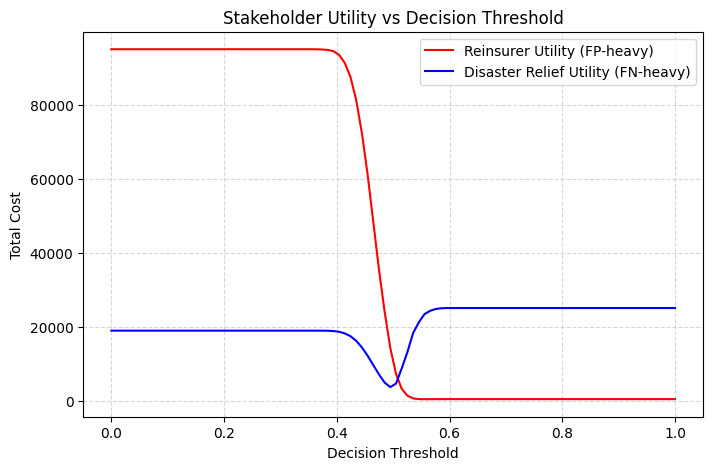

In [16]:
plt.figure(figsize=(8, 5))

plt.plot(thresholds, reinsurer_costs, label="Reinsurer Utility (FP-heavy)", color="red")
plt.plot(
    thresholds, ngo_costs, label="Disaster Relief Utility (FN-heavy)", color="blue"
)

plt.xlabel("Decision Threshold")
plt.ylabel("Total Cost")
plt.title("Stakeholder Utility vs Decision Threshold")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.5)

plt.show()

## 3. Risk-Conditioned Parametric Payout Structure
While the previous section identifies optimal binary trigger thresholds under stakeholder cost preferences, this section extends this framework by introducing a multi-tier payout structure that defines how financial compensation scales with predicted risk severity. 

To convert continuous flood risk predictions into an actionable insurance mechanism, we define a tiered payout function that maps XGBoost predicted probabilities (`xgb_pred`) into discrete payout levels. This allows the model to function as a financial decision system rather than a purely predictive tool.

We define four risk bands:

- Low risk (prob < 0.50): 0% payout, representing baseline conditions with no financial intervention.
- Moderate risk (0.50–0.70): 25% payout, representing early-stage response or mobilization support.
- High risk (0.70–0.85): 60% payout, representing major flood conditions with substantial expected losses.
- Catastrophic risk (≥ 0.85): 100% payout, representing extreme tail-risk events.

This step-function structure enables a smoother transition between risk levels compared to binary triggers, reducing the “cliff effect” where small changes in probability lead to large changes in payout. The thresholds are chosen to reflect low, moderate, high, and extreme risk regimes based on increasing segments of the predicted probability distribution, ensuring a monotonic escalation of payouts consistent with parametric insurance design principles.

We then apply the function to generate payout percentages and convert them into dollar terms using a fixed $100,000 policy limit per case. This policy limit serves as a standardized notional coverage amount, enabling consistent simulation of portfolio-level insurance liability.

In [11]:
def get_payout_factor(prob):
    if prob >= 0.85:
        return 1.00  # 100% Payout (Catastrophic)
    elif prob >= 0.70:
        return 0.60  # 60% Payout (Major)
    elif prob >= 0.50:
        return 0.25  # 25% Payout (Moderate/Mobilization)
    else:
        return 0.00  # 0% Payout (Baseline)


# Apply predictions
df["payout_percentage"] = df["xgb_pred"].apply(get_payout_factor)

# Calculate total simulated liability (assuming a $100,000 policy limit)
df["simulated_payout_usd"] = df["payout_percentage"] * 100000

## 4. Contract Visualization

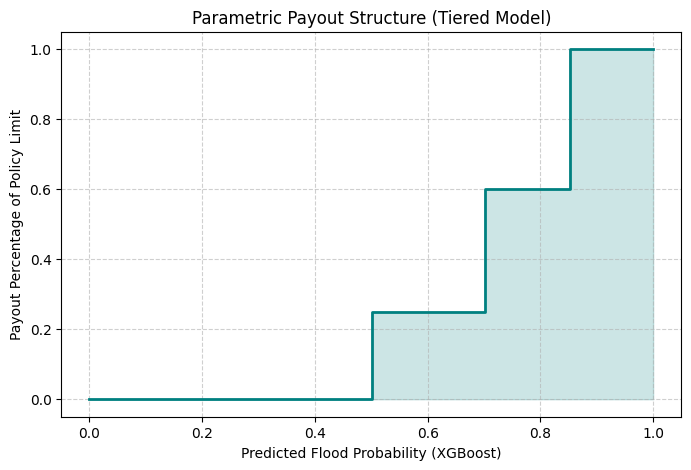

In [12]:
# Generate a range of probabilities to plot the curve
probs = np.linspace(0, 1, 500)
payouts = [get_payout_factor(p) for p in probs]

plt.figure(figsize=(8, 5))
plt.step(probs, payouts, where="post", color="teal", linewidth=2)
plt.fill_between(probs, payouts, step="post", alpha=0.2, color="teal")
plt.title("Parametric Payout Structure (Tiered Model)")
plt.xlabel("Predicted Flood Probability (XGBoost)")
plt.ylabel("Payout Percentage of Policy Limit")
plt.grid(True, linestyle="--", alpha=0.6)
plt.show()

## 5. Example of End-to-End Simulation

In [ ]:
# Full System Simulation with Optimal Thresholds and Tiered Payouts

# 0. Load data
df = pd.read_csv("data/test_predictions_for_trigger.csv")

# 1. Define catastrophe ground truth (top 10%)
threshold_event = df["true_probability"].quantile(0.90)
df["is_event"] = (df["true_probability"] >= threshold_event).astype(int)

# 2. Stakeholder optimal thresholds (from utility simulation)
optimal_reinsurer_threshold = thresholds[np.argmin(reinsurer_costs)]
optimal_ngo_threshold = thresholds[np.argmin(ngo_costs)]

# 3. Apply decision rules
df["reinsurer_trigger"] = (df["xgb_pred"] >= optimal_reinsurer_threshold).astype(int)
df["ngo_trigger"] = (df["xgb_pred"] >= optimal_ngo_threshold).astype(int)

# 4. Apply tiered payout function
df["payout_percentage"] = df["xgb_pred"].apply(get_payout_factor)
df["simulated_payout_usd"] = df["payout_percentage"] * 100000

# Output summary

print("Parametric System Output Summary:")

print("\nOptimal Thresholds:")
print("Reinsurer:", round(optimal_reinsurer_threshold, 3))
print("NGO:", round(optimal_ngo_threshold, 3))

print("\nEvent Rate (Ground Truth):", round(df["is_event"].mean(), 3))
print("Triggered Rate (Reinsurer):", round(df["reinsurer_trigger"].mean(), 3))
print("Triggered Rate (NGO):", round(df["ngo_trigger"].mean(), 3))

print("\nExpected Payout ($):", round(df["simulated_payout_usd"].mean(), 2))
print("Total Portfolio Liability ($):", round(df["simulated_payout_usd"].sum(), 2))

# show sample of final system output
df[
    [
        "xgb_pred",
        "is_event",
        "reinsurer_trigger",
        "ngo_trigger",
        "payout_percentage",
        "simulated_payout_usd",
    ]
].head()

Parametric System Output Summary:

Optimal Thresholds:
Reinsurer: 0.556
NGO: 0.495

Event Rate (Ground Truth): 0.109
Triggered Rate (Reinsurer): 0.003
Triggered Rate (NGO): 0.191

Expected Payout ($): 3792.5
Total Portfolio Liability ($): 37925000.0


,xgb_pred,is_event,reinsurer_trigger,ngo_trigger,payout_percentage,simulated_payout_usd
0,0.419325,0,0,0,0.0,0.0
1,0.451702,0,0,0,0.0,0.0
2,0.451725,0,0,0,0.0,0.0
3,0.464199,0,0,0,0.0,0.0
4,0.471838,0,0,0,0.0,0.0
